# Day 21 — SQL Historical Portfolio Backtesting

Strategy: Equal-weight buy-and-hold portfolio
Initial capital: $100,000
Assets: AAPL, BLK, GS, JPM, MSFT

In [1]:

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

conn = sqlite3.connect("hedge_fund.db")

prices = pd.read_sql_query("""
SELECT
    date,
    ticker,
    close_price
FROM daily_prices
WHERE ticker IN ('AAPL', 'BLK', 'GS', 'JPM', 'MSFT')
ORDER BY date, ticker
""", conn)

prices["date"] = pd.to_datetime(prices["date"])

price_matrix = prices.pivot(
    index="date",
    columns="ticker",
    values="close_price"
).sort_index()

if price_matrix.isna().any().any():
    raise ValueError("Missing prices detected.")

if (price_matrix <= 0).any().any():
    raise ValueError("Invalid prices detected.")

display(price_matrix.head())
print("Trading days:", len(price_matrix))

ticker,AAPL,BLK,GS,JPM,MSFT
date,,,,,
2025-09-23,253.493591,1108.070068,790.766968,306.869354,505.074463
2025-09-24,251.381409,1104.378906,777.144836,307.536621,505.986908
2025-09-25,255.924637,1123.284790,779.429932,307.566071,502.892334
2025-09-26,254.519806,1132.253052,787.030518,310.127045,507.286194
2025-09-29,253.493591,1150.963501,788.609436,309.764008,510.400513


Trading days: 250


In [2]:

initial_capital = 100_000

tickers = price_matrix.columns.tolist()
allocation = initial_capital / len(tickers)

first_prices = price_matrix.iloc[0]

shares = allocation / first_prices

holdings = pd.DataFrame({
    "ticker": tickers,
    "initial_price": first_prices.values,
    "initial_investment": allocation,
    "shares": shares.values
})

display(holdings)

,ticker,initial_price,initial_investment,shares
0,AAPL,253.493591,20000.0,78.897458
1,BLK,1108.070068,20000.0,18.049400
2,GS,790.766968,20000.0,25.291901
3,JPM,306.869354,20000.0,65.174315
4,MSFT,505.074463,20000.0,39.598122


In [3]:

# Buy once and hold the same number of shares
daily_holdings_value = price_matrix.mul(
    shares, axis=1
)

backtest = pd.DataFrame(index=price_matrix.index)

backtest["portfolio_equity"] = (
    daily_holdings_value.sum(axis=1)
)

backtest["daily_return"] = (
    backtest["portfolio_equity"].pct_change()
)

backtest["cumulative_return_pct"] = (
    backtest["portfolio_equity"] / initial_capital - 1
) * 100

backtest["running_peak"] = (
    backtest["portfolio_equity"].cummax()
)

backtest["drawdown_pct"] = (
    backtest["portfolio_equity"]
    / backtest["running_peak"] - 1
) * 100

display(backtest.head())

,portfolio_equity,daily_return,cumulative_return_pct,running_peak,drawdown_pct
date,,,,,
2025-09-23,100000.000000,NaN,0.000000,100000.000000,0.000000
2025-09-24,99501.821069,-0.004982,-0.498179,100000.000000,-0.498179
2025-09-25,100138.684517,0.006401,0.138685,100138.684517,0.000000
2025-09-26,100722.850271,0.005834,0.722850,100722.850271,0.000000
2025-09-29,101119.191263,0.003935,1.119191,101119.191263,0.000000


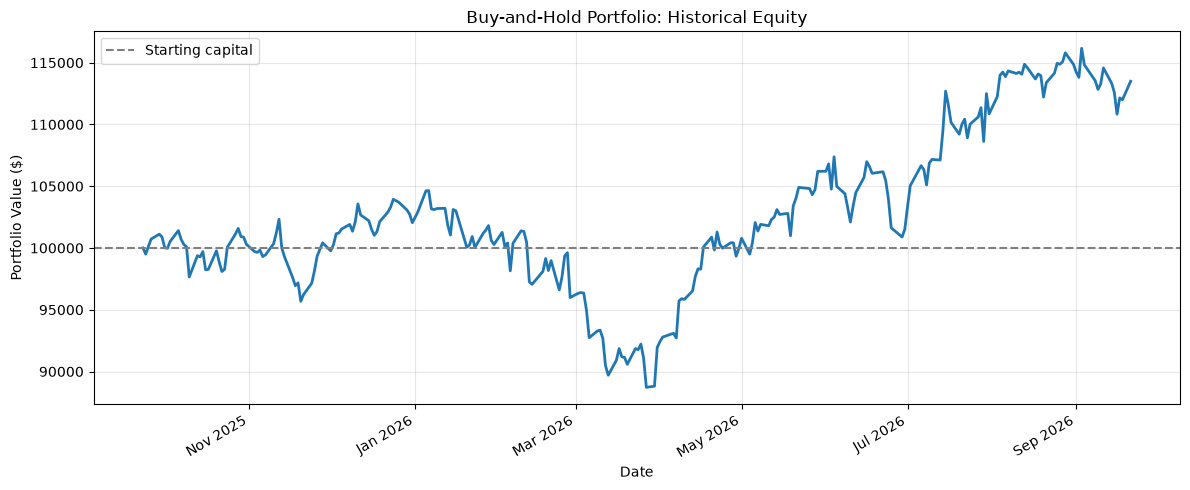

In [4]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    backtest.index,
    backtest["portfolio_equity"],
    linewidth=2
)

ax.axhline(
    initial_capital,
    linestyle="--",
    color="gray",
    label="Starting capital"
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.set_title("Buy-and-Hold Portfolio: Historical Equity")
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.legend()
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [5]:

# Day 21: Historical backtest performance metrics

daily_returns = backtest["daily_return"].dropna()
equity = backtest["portfolio_equity"]

total_return = equity.iloc[-1] / initial_capital - 1

annualized_return = (
    (equity.iloc[-1] / initial_capital)
    ** (252 / len(daily_returns)) - 1
)

annualized_volatility = (
    daily_returns.std() * np.sqrt(252)
)

# Assume a zero risk-free rate for this exercise
sharpe_ratio = (
    daily_returns.mean() * 252
    / annualized_volatility
    if annualized_volatility > 0
    else np.nan
)

max_drawdown = backtest["drawdown_pct"].min()

performance = pd.DataFrame({
    "Metric": [
        "Initial Capital",
        "Final Portfolio Value",
        "Total Return",
        "Annualized Return",
        "Annualized Volatility",
        "Sharpe Ratio (Rf = 0%)",
        "Maximum Drawdown"
    ],
    "Value": [
        f"${initial_capital:,.2f}",
        f"${equity.iloc[-1]:,.2f}",
        f"{total_return:.2%}",
        f"{annualized_return:.2%}",
        f"{annualized_volatility:.2%}",
        f"{sharpe_ratio:.2f}",
        f"{max_drawdown:.2f}%"
    ]
})

display(performance)


,Metric,Value
0,Initial Capital,"$100,000.00"
1,Final Portfolio Value,"$113,494.96"
2,Total Return,13.49%
3,Annualized Return,13.67%
4,Annualized Volatility,18.26%
5,Sharpe Ratio (Rf = 0%),0.79
6,Maximum Drawdown,-15.22%


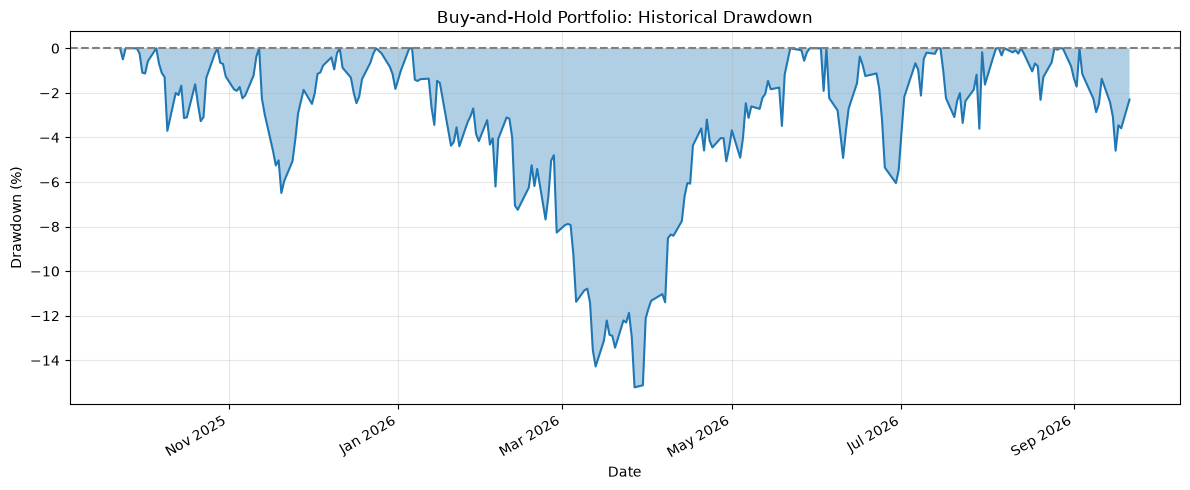

In [6]:

fig, ax = plt.subplots(figsize=(12, 5))

ax.fill_between(
    backtest.index,
    backtest["drawdown_pct"],
    0,
    alpha=0.35
)

ax.plot(
    backtest.index,
    backtest["drawdown_pct"],
    linewidth=1.5
)

ax.axhline(0, linestyle="--", color="gray")

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

ax.set_title("Buy-and-Hold Portfolio: Historical Drawdown")
ax.set_xlabel("Date")
ax.set_ylabel("Drawdown (%)")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [7]:

final_values = daily_holdings_value.iloc[-1]

final_allocation = pd.DataFrame({
    "Ticker": final_values.index,
    "Initial Weight (%)": 20.0,
    "Final Value ($)": final_values.values,
    "Final Weight (%)": (
        final_values.values
        / final_values.sum() * 100
    )
})

display(final_allocation.round(2))

,Ticker,Initial Weight (%),Final Value ($),Final Weight (%)
0,AAPL,20.0,26744.66,23.56
1,BLK,20.0,19678.72,17.34
2,GS,20.0,24264.80,21.38
3,JPM,20.0,22943.97,20.22
4,MSFT,20.0,19862.81,17.50
